# FMA Music Genre Classification (Kaggle)

The genre classifier, adapted to run on Kaggle - no 22 GB download, no Google Drive.
Mel-spectrograms -> fine-tuned ResNet, with class weighting and macro-F1 so the heavy
genre imbalance can't fake a good score.

**Before running:** Add Data -> attach *"FMA - Free Music Archive - Small & Medium"*
(by imsparsh). Then Settings -> Accelerator -> **GPU (T4)**, and run top to bottom.

## 0. Find the data, check the GPU
Kaggle mounts the dataset read-only under `/kaggle/input`. We locate `tracks.csv` and build
a `track_id -> mp3` map by globbing, so it works whatever the folder layout is. **Check the
printed mp3 count:** ~25,000 means you have medium; ~8,000 means only the small subset is
present (then set `SUBSET = 'small'` below - it's the balanced 8-genre task).

In [2]:
import os, glob, numpy as np, torch
print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "(enable GPU!)")

TRACKS_CSV = glob.glob('/kaggle/input/**/tracks.csv', recursive=True)[0]
all_mp3 = glob.glob('/kaggle/input/**/*.mp3', recursive=True)
id_to_path = {int(os.path.splitext(os.path.basename(p))[0]): p for p in all_mp3}
print("tracks.csv:", TRACKS_CSV)
print("mp3 files found:", len(id_to_path))

WORK = '/kaggle/working'
def audio_path(track_id):
    return id_to_path[track_id]

CUDA: True Tesla T4
tracks.csv: /kaggle/input/datasets/imsparsh/fma-free-music-archive-small-medium/fma_metadata/tracks.csv
mp3 files found: 25000


## 1. Libraries

In [6]:
import fastai, librosa
print("fastai", fastai.__version__, "| librosa", librosa.__version__)

fastai 2.8.7 | librosa 0.11.0


## 2. Read the labels
`medium` contains `small`, so we select both to get all ~25,000 tracks (16 genres). We keep
the official train/val/test split, drop tracks with no top genre, and keep only clips whose
audio we actually have.

In [7]:
import pandas as pd
SUBSET = 'medium'                                  # 'medium' (16 genres) or 'small' (8, balanced)
sel = ['small', 'medium'] if SUBSET == 'medium' else ['small']

tracks = pd.read_csv(TRACKS_CSV, index_col=0, header=[0, 1])
subset = tracks[('set', 'subset')]
sub = tracks[subset.isin(sel)]
df = pd.DataFrame({
    'track_id': sub.index,
    'genre':    sub[('track', 'genre_top')].values,
    'split':    sub[('set', 'split')].values,
}).dropna(subset=['genre'])
df = df[df['track_id'].isin(id_to_path)]
print(df.shape, "| genres:", df['genre'].nunique())
print(df['genre'].value_counts())

(25000, 3) | genres: 16
genre
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64


## 3. Audio -> mel-spectrogram images
Each clip becomes a log-mel PNG under `spectrograms/<split>/<genre>/<id>.png`, written to
`/kaggle/working`. We sanitize genre names (`Old-Time / Historic` contains a `/`, which would
otherwise split into folders). Cached, so reruns skip finished images. ~25k clips is the slow
step (~30-60 min the first time).

In [6]:
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

SPEC_DIR = Path(WORK) / 'spectrograms'
SR, N_MELS, N_FFT, HOP = 22050, 128, 2048, 512

def make_spectrogram(track_id, out_path):
    y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP)
    S_db = librosa.power_to_db(S, ref=np.max)
    S_norm = ((S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-9) * 255).astype(np.uint8)
    Image.fromarray(np.flipud(S_norm)).save(out_path)

skipped = 0
for row in tqdm(df.itertuples(index=False), total=len(df)):
    genre = str(row.genre).replace('/', '-')        # filesystem-safe label
    out_dir = SPEC_DIR / row.split / genre
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{row.track_id}.png'
    if out_path.exists():
        continue
    try:
        make_spectrogram(int(row.track_id), out_path)
    except Exception:
        skipped += 1
print("Done. Skipped (corrupt) clips:", skipped)

  0%|          | 0/25000 [00:00<?, ?it/s]

/tmp/ipykernel_58/3634347508.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_58/3634347508.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path(track_id), sr=SR, mono=True, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/pa

Done. Skipped (corrupt) clips: 15


## 4. Build the DataLoaders
Resize every spectrogram to 224x224 the **same way** for train and validation (`Squish`),
and normalize with ImageNet stats so the pretrained model sees its expected input range.

In [5]:
from pathlib import Path
import glob
WORK = '/kaggle/working'
SPEC_DIR = Path(WORK) / 'spectrograms'
print("spectrograms on disk:", len(glob.glob(str(SPEC_DIR/'**'/'*.png'), recursive=True)))

spectrograms on disk: 0


In [8]:
import glob
from pathlib import Path

cands = glob.glob('/kaggle/input/**/training', recursive=True)
cands = [c for c in cands if glob.glob(c + '/**/*.png', recursive=True)]
print("candidates:", cands)

SPEC_DIR = Path(cands[0]).parent          # the folder containing training/validation/test
print("SPEC_DIR =", SPEC_DIR)
print("spectrograms found:", len(glob.glob(str(SPEC_DIR/'**'/'*.png'), recursive=True)))

candidates: ['/kaggle/input/notebooks/zhihaomu/fma-music-genre-classification/spectrograms/training']
SPEC_DIR = /kaggle/input/notebooks/zhihaomu/fma-music-genre-classification/spectrograms
spectrograms found: 24985


In [9]:
from fastai.vision.all import *

dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=lambda src: get_image_files(src/'training') + get_image_files(src/'validation'),
    get_y=parent_label,
    splitter=FuncSplitter(lambda o: Path(o).parent.parent.name == 'validation'),
    item_tfms=Resize(224, method=ResizeMethod.Squish),
    batch_tfms=Normalize.from_stats(*imagenet_stats),
).dataloaders(SPEC_DIR, bs=64)

print("Genres (%d):" % len(dls.vocab), list(dls.vocab))
print("train / valid sizes:", len(dls.train_ds), len(dls.valid_ds))

Genres (16): ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time - Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']
train / valid sizes: 19909 2504


## 5. Class weights + honest metrics
Inverse-frequency weights stop Rock/Electronic from dominating; macro-F1 reports performance
averaged over genres, not over clips.

In [10]:
from collections import Counter
train_files = get_image_files(SPEC_DIR/'training')
cnt     = Counter(parent_label(f) for f in train_files)
counts  = tensor([cnt[c] for c in dls.vocab]).float()
weights = (counts.sum() / (len(counts) * counts)).to(dls.device)



w = (counts.mean() / counts).sqrt().clamp(max=3.0)
loss = CrossEntropyLossFlat(weight=w.to(dls.device), label_smoothing=0.1)

metrics = [accuracy, F1Score(average='macro')]
print("per-class training counts:", {c: int(n) for c, n in zip(dls.vocab, counts)})

per-class training counts: {'Blues': 58, 'Classical': 495, 'Country': 142, 'Easy Listening': 13, 'Electronic': 5048, 'Experimental': 1800, 'Folk': 1214, 'Hip-Hop': 1757, 'Instrumental': 1044, 'International': 814, 'Jazz': 306, 'Old-Time - Historic': 408, 'Pop': 945, 'Rock': 5677, 'Soul-RnB': 94, 'Spoken': 94}


## 6. Train - fine-tune a pretrained ResNet34
The strong baseline for the product. (To train **your own CNN from scratch** instead, skip
this cell and run the optional cell below it.)

In [11]:

learn = vision_learner(dls, 'convnext_tiny.fb_in22k', loss_func=loss, metrics=metrics,
                       cbs=[MixUp(),
                            SaveModelCallback(monitor='f1_score')]).to_fp16()
learn.fine_tune(16, base_lr=1e-3, freeze_epochs=2)

model.safetensors:   0%|          | 0.00/178M [00:00<?, ?B/s]

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.802793,2.599473,0.512380,0.300992,01:36
1,2.259800,2.346208,0.588658,0.357894,01:25


Better model found at epoch 0 with f1_score value: 0.30099201190825264.
Better model found at epoch 1 with f1_score value: 0.35789354958844755.


epoch,train_loss,valid_loss,accuracy,f1_score,time
0,2.067098,2.260784,0.613818,0.385972,01:55
1,2.019616,2.235468,0.623003,0.399494,01:51
2,1.953067,2.206474,0.624601,0.403915,01:51
3,1.912098,2.203275,0.638578,0.416359,01:51
4,1.864024,2.183875,0.643770,0.428205,01:51
5,1.831855,2.152407,0.657748,0.443939,01:51
6,1.784149,2.142390,0.655751,0.450898,01:51
7,1.770482,2.132988,0.658946,0.436644,01:51
8,1.737126,2.131968,0.654553,0.443822,01:51
9,1.709909,2.126855,0.660144,0.442266,01:51


Better model found at epoch 0 with f1_score value: 0.3859723454609779.
Better model found at epoch 1 with f1_score value: 0.39949391107302284.
Better model found at epoch 2 with f1_score value: 0.4039148519455842.
Better model found at epoch 3 with f1_score value: 0.41635899467441134.
Better model found at epoch 4 with f1_score value: 0.4282049324496264.
Better model found at epoch 5 with f1_score value: 0.44393900783189144.
Better model found at epoch 6 with f1_score value: 0.45089785809552935.
Better model found at epoch 12 with f1_score value: 0.4592204686322915.


### 6b. (Optional) Your own CNN instead of ResNet
Run this **instead of** the cell above to use the hand-built network. It trains from random
weights, so it scores lower but is fully yours.

In [ ]:
from fastai.vision.all import *      # provides Learner; harmless if already imported
import torch.nn as nn

def conv_block(ic, oc):
    return nn.Sequential(nn.Conv2d(ic, oc, 3, padding=1), nn.BatchNorm2d(oc),
                         nn.ReLU(inplace=True), nn.MaxPool2d(2))

class SimpleCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.body = nn.Sequential(conv_block(3,32), conv_block(32,64), conv_block(64,128),
                                  conv_block(128,256), conv_block(256,256))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(256, n))
    def forward(self, x): return self.head(self.body(x))


learn_cnn = Learner(dls, SimpleCNN(len(dls.vocab)), loss_func=loss, metrics=metrics,
                    cbs=[SaveModelCallback(monitor='f1_score', fname='best_cnn')]).to_fp16()
learn_cnn.fit_one_cycle(30, lr_max=2e-3, wd=0.1)

epoch,train_loss,valid_loss,accuracy,f1_score,time
0,4.552712,7.453983,0.029153,0.111170,01:12
1,4.343426,7.567716,0.024361,0.059140,00:59
2,4.385336,7.532801,0.036342,0.118771,00:59
3,4.439867,7.413462,0.029553,0.102578,01:00
4,4.325073,7.663584,0.029553,0.086415,01:00
5,4.218684,7.493932,0.046725,0.110041,00:59
6,4.347390,7.796167,0.091853,0.197704,00:59
7,4.213311,7.490061,0.047923,0.142521,00:58
8,4.219087,7.474612,0.040735,0.128874,00:58
9,4.168899,7.409488,0.081070,0.194797,00:58


## 7. Per-genre breakdown
The headline accuracy hides the rare genres; the classification report and confusion matrix
show them.

                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.76      0.90      0.82        62
            Country       0.33      0.17      0.22        18
     Easy Listening       0.00      0.00      0.00         2
         Electronic       0.68      0.76      0.72       631
       Experimental       0.47      0.47      0.47       225
               Folk       0.57      0.68      0.62       152
            Hip-Hop       0.72      0.73      0.72       220
       Instrumental       0.30      0.29      0.30       131
      International       0.59      0.68      0.63       102
               Jazz       0.26      0.21      0.23        39
Old-Time - Historic       0.91      0.76      0.83        51
                Pop       0.13      0.09      0.11       122
               Rock       0.88      0.82      0.85       711
           Soul-RnB       0.15      0.11      0.13        18
             Spoken    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


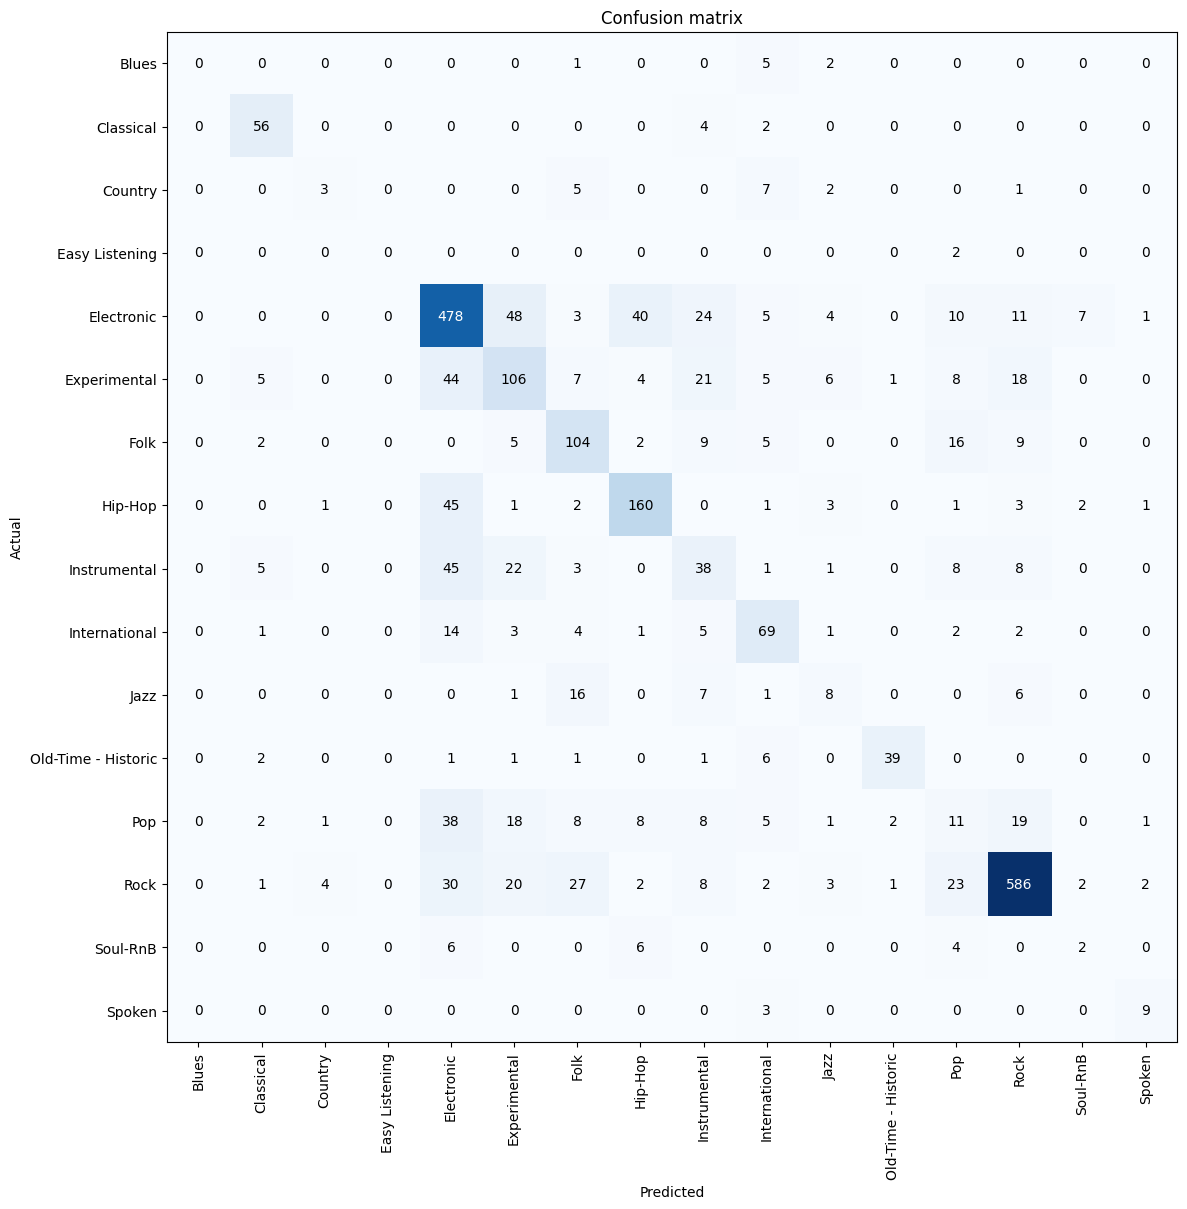

In [12]:
interp = ClassificationInterpretation.from_learner(learn)
print(interp.print_classification_report())
interp.plot_confusion_matrix(figsize=(12, 12))

Comparison between the Pre-trained model vs Simple CNN

In [ ]:
from sklearn.metrics import f1_score
test_files = get_image_files(SPEC_DIR/'test')
for name, l in [('ResNet34 (transfer learning)', learn),
                ('SimpleCNN (from scratch)',     learn_cnn)]:
    dl = l.dls.test_dl(test_files, with_labels=True)
    preds, targs = l.get_preds(dl=dl)
    print(f"{name}: accuracy {accuracy(preds, targs).item():.3f} | "
          f"macro-F1 {f1_score(targs, preds.argmax(1), average='macro'):.3f}")

## 8. Held-out test score + save the model
This `.pkl` is the classifier your website will load.

In [14]:
from sklearn.metrics import f1_score
test_files = get_image_files(SPEC_DIR/'test')
test_dl = learn.dls.test_dl(test_files, with_labels=True)
preds, targs = learn.get_preds(dl=test_dl)
print(f"Test accuracy: {accuracy(preds, targs).item():.4f}")
print(f"Test macro-F1: {f1_score(targs, preds.argmax(1), average='macro'):.4f}")

learn.export(f'{WORK}/genre_resnet34_{SUBSET}.pkl')
print("Saved:", f'{WORK}/genre_resnet34_{SUBSET}.pkl')

Test accuracy: 0.6481
Test macro-F1: 0.4449
Saved: /kaggle/working/genre_resnet34_medium.pkl


In [15]:
import sys, torch, fastai, fastcore, timm
print(sys.version.split()[0], "| torch", torch.__version__, "| fastai", fastai.__version__,
      "| fastcore", fastcore.__version__, "| timm", timm.__version__)

3.12.13 | torch 2.10.0+cu128 | fastai 2.8.7 | fastcore 1.12.36 | timm 1.0.26


## Notes for Kaggle
- **Don't regenerate every session.** `/kaggle/working` is wiped when the session ends. To
  avoid the ~30-60 min spectrogram step next time, click *Save Version* (runs top-to-bottom
  and stores the output), or save the `spectrograms/` folder as a new Kaggle Dataset and
  attach it - then Step 3 finds them cached and skips straight to training.
- **For the website:** download `genre_resnet34_*.pkl` from the notebook's Output tab; the
  app loads it with `load_learner(...)`.

In [24]:
# ============ PLAIN EXPORT — pure-torch model file ============
ARCH = 'convnext_tiny.fb_in22k'      # the timm arch you trained

import torch, torch.nn as nn, torch.nn.functional as F, timm

model = learn.model.eval().float().cpu()
body_fastai, head_fastai = model[0], model[1]
body_raw = getattr(body_fastai, 'model', body_fastai)   # unwrap TimmBody

# --- describe the head as a plain spec ---
spec = []
for m in head_fastai.children():
    n = type(m).__name__
    if n == 'AdaptiveConcatPool2d':      spec.append(['concat_pool'])
    elif n == 'Flatten':                 spec.append(['flatten'])
    elif isinstance(m, nn.BatchNorm1d):  spec.append(['bn', m.num_features])
    elif isinstance(m, nn.Dropout):      spec.append(['dropout', m.p])
    elif isinstance(m, nn.Linear):       spec.append(['linear', m.in_features,
                                                      m.out_features,
                                                      m.bias is not None])
    elif isinstance(m, nn.ReLU):         spec.append(['relu'])
    else:
        print(head_fastai); raise ValueError(f'unexpected head layer: {n}')

# --- rebuild in plain torch and VERIFY ---
class ConcatPool(nn.Module):
    def forward(self, x):
        return torch.cat([F.adaptive_max_pool2d(x, 1),
                          F.adaptive_avg_pool2d(x, 1)], dim=1)

def build_head(spec):
    L = []
    for s in spec:
        k = s[0]
        if k == 'concat_pool': L.append(ConcatPool())
        elif k == 'flatten':   L.append(nn.Flatten(1))
        elif k == 'bn':        L.append(nn.BatchNorm1d(s[1]))
        elif k == 'dropout':   L.append(nn.Dropout(s[1]))
        elif k == 'linear':    L.append(nn.Linear(s[1], s[2], bias=s[3]))
        elif k == 'relu':      L.append(nn.ReLU(inplace=True))
    return nn.Sequential(*L)

class FeatureBody(nn.Module):
    """fastai's TimmBody calls forward_features(), NOT the full forward()
    — the full forward would also apply timm's own head norm/pool."""
    def __init__(self, m):
        super().__init__(); self.m = m
    def forward(self, x):
        return self.m.forward_features(x)

body2 = timm.create_model(ARCH, pretrained=False, num_classes=0)
body2.load_state_dict(body_raw.state_dict())
head2 = build_head(spec); head2.load_state_dict(head_fastai.state_dict())
plain = nn.Sequential(FeatureBody(body2), head2).eval()

x = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    diff = (plain(x) - model(x)).abs().max().item()
print('max output diff:', diff)
assert diff < 1e-4, 'rebuild mismatch — send Claude the printed head above'

torch.save({'arch': ARCH, 'vocab': list(learn.dls.vocab), 'head_spec': spec,
            'body_sd': body2.state_dict(), 'head_sd': head2.state_dict()},
           '/kaggle/working/genre_model_plain.pt')
print('SAVED genre_model_plain.pt | genres:', list(learn.dls.vocab))
# ===============================================================

max output diff: 0.0
SAVED genre_model_plain.pt | genres: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time - Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


In [26]:
# ============ ARTIFACTS EXPORT ============
import os, glob, shutil, random, zipfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report
from fastai.vision.all import ClassificationInterpretation, get_image_files

OUT = '/kaggle/working/app_artifacts'; os.makedirs(OUT, exist_ok=True)

# 1. Confusion matrix + per-class F1 (validation set)
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(10, 10))
plt.savefig(f'{OUT}/confusion_matrix.png', bbox_inches='tight'); plt.close('all')

preds, targs = learn.get_preds()
vocab = list(learn.dls.vocab)
rep = classification_report(targs.numpy(), preds.argmax(1).numpy(),
                            target_names=vocab, output_dict=True)
pd.DataFrame([{'genre': g, 'precision': rep[g]['precision'],
               'recall': rep[g]['recall'], 'f1': rep[g]['f1-score'],
               'support': int(rep[g]['support'])} for g in vocab]
             ).round(3).to_csv(f'{OUT}/per_class_f1.csv', index=False)

# 2. Embeddings with the PLAIN model (must match app.py's embed_clip)
#    Names use artist/title from tracks.csv (`tracks` from the labels cell).
import torch
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]

meta_a, meta_t = tracks[('artist', 'name')], tracks[('track', 'title')]
def track_name(tid, genre):
    a, t = meta_a.get(tid), meta_t.get(tid)
    a = str(a) if pd.notna(a) else 'Unknown artist'
    t = str(t) if pd.notna(t) else f'track {tid}'
    return f'{a} — {t}  ({genre})'
def prep(png):
    img = Image.open(png).convert('RGB').resize((224, 224))
    t = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.
    return (t - IMAGENET_MEAN) / IMAGENET_STD

plain_gpu = plain.cuda().eval()
val_pngs = get_image_files(SPEC_DIR/'validation')
embs, names = [], []
with torch.no_grad():
    for i in range(0, len(val_pngs), 64):
        batch = torch.stack([prep(p) for p in val_pngs[i:i+64]]).cuda()
        f = plain_gpu[0](batch)
        v = ConcatPool()(f).flatten(1).cpu().numpy()
        embs.append(v)
        names += [track_name(int(p.stem), p.parent.name)
                  for p in val_pngs[i:i+64]]
embs = np.concatenate(embs).astype(np.float32)
np.savez_compressed(f'{OUT}/embeddings.npz', emb=embs,
                    names=np.array(names, dtype=object))
plain = plain.cpu()

# 3. Sample clips: 2 mp3s per genre, named "Artist - Title.mp3"
#    (uses df + id_to_path from cells 0/2)
import re
def safe(s, n=60):
    return re.sub(r'[^\w\- .,()]', '', str(s))[:n].strip() or 'unknown'

for g in df['genre'].unique():
    ids = df[df['genre'] == g]['track_id'].sample(2, random_state=0)
    d = f"{OUT}/samples/{str(g).replace('/', '-')}"; os.makedirs(d, exist_ok=True)
    for tid in ids:
        tid = int(tid)
        dst = f"{d}/{safe(f'{meta_a.get(tid)} - {meta_t.get(tid)}')}.mp3"
        if os.path.exists(dst):
            dst = dst[:-4] + f' [{tid}].mp3'
        shutil.copy(id_to_path[tid], dst)

# 4. Zip
with zipfile.ZipFile('/kaggle/working/app_artifacts.zip', 'w') as z:
    for root, _, files in os.walk(OUT):
        for f in files:
            fp = os.path.join(root, f)
            z.write(fp, os.path.relpath(fp, OUT))
print('DONE -> download /kaggle/working/app_artifacts.zip')
# ==========================================

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


DONE -> download /kaggle/working/app_artifacts.zip
